# Day 2 — RFM Segmentation
## SNB Customer Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['axes.unicode_minus'] = False

print("Libraries loaded ")

Libraries loaded 


In [3]:
customers    = pd.read_csv('../Data/clean/snb_customers_clean.csv', 
                           parse_dates=['join_date'])
transactions = pd.read_csv('../Data/clean/snb_transactions_clean.csv', 
                           parse_dates=['date'])

print(f"Customers:    {len(customers):,}")
print(f"Transactions: {len(transactions):,}")
print()
print("Transactions columns:", transactions.columns.tolist())
print()
print(transactions.head(3))

Customers:    5,000
Transactions: 73,522

Transactions columns: ['transaction_id', 'customer_id', 'date', 'type', 'amount', 'product', 'month']

  transaction_id customer_id       date        type   amount       product  \
0      TX0000000    SNB00001 2026-01-31       إيداع  3050.41       استثمار   
1      TX0000001    SNB00001 2026-05-19       تحويل  7001.16  بطاقة ائتمان   
2      TX0000002    SNB00001 2026-02-04  دفع فاتورة  9922.57   تمويل عقاري   

   month  
0      1  
1      5  
2      2  


In [4]:
customers    = pd.read_csv('../Data/clean/snb_customers_clean.csv', 
                           parse_dates=['join_date'])
transactions = pd.read_csv('../Data/clean/snb_transactions_clean.csv', 
                           parse_dates=['date'])

print(f"Customers:    {len(customers):,}")
print(f"Transactions: {len(transactions):,}")
print()
print("Transactions columns:", transactions.columns.tolist())
print()
print(transactions.head(3))

Customers:    5,000
Transactions: 73,522

Transactions columns: ['transaction_id', 'customer_id', 'date', 'type', 'amount', 'product', 'month']

  transaction_id customer_id       date        type   amount       product  \
0      TX0000000    SNB00001 2026-01-31       إيداع  3050.41       استثمار   
1      TX0000001    SNB00001 2026-05-19       تحويل  7001.16  بطاقة ائتمان   
2      TX0000002    SNB00001 2026-02-04  دفع فاتورة  9922.57   تمويل عقاري   

   month  
0      1  
1      5  
2      2  


In [5]:

reference_date = transactions['date'].max()
print(f"Reference date: {reference_date.date()}")

rfm = transactions.groupby('customer_id').agg(
    Recency   = ('date',   lambda x: (reference_date - x.max()).days),
    Frequency = ('transaction_id', 'count'),
    Monetary  = ('amount', 'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f"\nRFM Table shape: {rfm.shape}")
print(f"\nSample:")
print(rfm.head(8).to_string(index=False))
print(f"\nStats:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(1))

Reference date: 2026-12-31

RFM Table shape: (5000, 4)

Sample:
customer_id  Recency  Frequency  Monetary
   SNB00001      203          6  45057.88
   SNB00002       77          3  15553.53
   SNB00003       44         10 260549.58
   SNB00004        0         17 129211.03
   SNB00005       40         17 391012.81
   SNB00006       56         18 127373.90
   SNB00007        8         19 578172.03
   SNB00008       14         10 235634.12

Stats:
       Recency  Frequency   Monetary
count   5000.0     5000.0     5000.0
mean      40.2       14.7   529183.7
std       55.0       11.2  1247228.6
min        0.0        1.0       54.0
25%        7.0        7.0    51900.5
50%       21.0       13.0   100878.3
75%       49.0       18.0   165393.9
max      364.0       60.0  6919224.4


In [6]:
rfm['R'] = pd.qcut(rfm['Recency'], 
                   q=5, 
                   labels=[5,4,3,2,1]).astype(int)

rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 
                   q=5, 
                   labels=[1,2,3,4,5]).astype(int)

rfm['M'] = pd.qcut(rfm['Monetary'].rank(method='first'), 
                   q=5, 
                   labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Total'] = rfm['R'] + rfm['F'] + rfm['M']

print("Sample with scores:")
print(rfm.head(8).to_string(index=False))
print()
print("Score distribution:")
print(rfm['RFM_Total'].describe().round(1))

Sample with scores:
customer_id  Recency  Frequency  Monetary  R  F  M  RFM_Total
   SNB00001      203          6  45057.88  1  1  2          4
   SNB00002       77          3  15553.53  1  1  1          3
   SNB00003       44         10 260549.58  2  2  4          8
   SNB00004        0         17 129211.03  5  4  4         13
   SNB00005       40         17 391012.81  2  4  5         11
   SNB00006       56         18 127373.90  2  4  4         10
   SNB00007        8         19 578172.03  4  4  5         13
   SNB00008       14         10 235634.12  4  2  4         10

Score distribution:
count    5000.0
mean        9.0
std         3.7
min         3.0
25%         6.0
50%         9.0
75%        12.0
max        15.0
Name: RFM_Total, dtype: float64


In [7]:

def assign_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    
    if   r >= 4 and f >= 4 and m >= 4: return 'Champions'
    elif r >= 3 and f >= 3:             return 'Loyal Customers'
    elif r >= 4 and f <= 2:             return 'New Customers'
    elif r <= 2 and f >= 3:             return 'At Risk'
    elif r <= 2 and f <= 2:             return 'Lost'
    else:                               return 'Potential'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

counts = rfm['Segment'].value_counts()
total  = len(rfm)

print("Segment Distribution:")
print("-" * 40)
for seg, cnt in counts.items():
    pct = cnt / total * 100
    bar = '█' * int(pct / 2)
    print(f"{seg:<20} {cnt:>4}  {pct:4.1f}%  {bar}")

print("-" * 40)
print(f"{'Total':<20} {total:>4}")

Segment Distribution:
----------------------------------------
Lost                 1290  25.8%  ████████████
Loyal Customers      1277  25.5%  ████████████
Champions            1050  21.0%  ██████████
At Risk               673  13.5%  ██████
New Customers         408   8.2%  ████
Potential             302   6.0%  ███
----------------------------------------
Total                5000


In [8]:


summary = rfm.groupby('Segment').agg(
    Count        = ('customer_id', 'count'),
    Avg_Recency  = ('Recency',   'mean'),
    Avg_Frequency= ('Frequency', 'mean'),
    Avg_Monetary = ('Monetary',  'mean'),
    Avg_RFM      = ('RFM_Total', 'mean')
).round(1).reset_index()

summary['Revenue_Share%'] = (
    rfm.groupby('Segment')['Monetary'].sum() /
    rfm['Monetary'].sum() * 100
).round(1).values

summary = summary.sort_values('Avg_Monetary', ascending=False)

print(summary.to_string(index=False))

        Segment  Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_RFM  Revenue_Share%
      Champions   1050          5.7           28.3     1795312.3     13.9            71.2
Loyal Customers   1277         14.7           16.7      374082.6     10.8            18.1
        At Risk    673         50.4           16.3      280967.2      9.0             7.1
      Potential    302         22.0            6.8       60732.8      6.5             0.7
  New Customers    408          6.3            7.2       60529.7      8.1             0.9
           Lost   1290        103.2            5.0       39541.6      4.2             1.9


In [9]:


summary = rfm.groupby('Segment').agg(
    Count        = ('customer_id', 'count'),
    Avg_Recency  = ('Recency',   'mean'),
    Avg_Frequency= ('Frequency', 'mean'),
    Avg_Monetary = ('Monetary',  'mean'),
    Avg_RFM      = ('RFM_Total', 'mean')
).round(1).reset_index()

summary['Revenue_Share%'] = (
    rfm.groupby('Segment')['Monetary'].sum() /
    rfm['Monetary'].sum() * 100
).round(1).values

summary = summary.sort_values('Avg_Monetary', ascending=False)
print(summary.to_string(index=False))

        Segment  Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_RFM  Revenue_Share%
      Champions   1050          5.7           28.3     1795312.3     13.9            71.2
Loyal Customers   1277         14.7           16.7      374082.6     10.8            18.1
        At Risk    673         50.4           16.3      280967.2      9.0             7.1
      Potential    302         22.0            6.8       60732.8      6.5             0.7
  New Customers    408          6.3            7.2       60529.7      8.1             0.9
           Lost   1290        103.2            5.0       39541.6      4.2             1.9


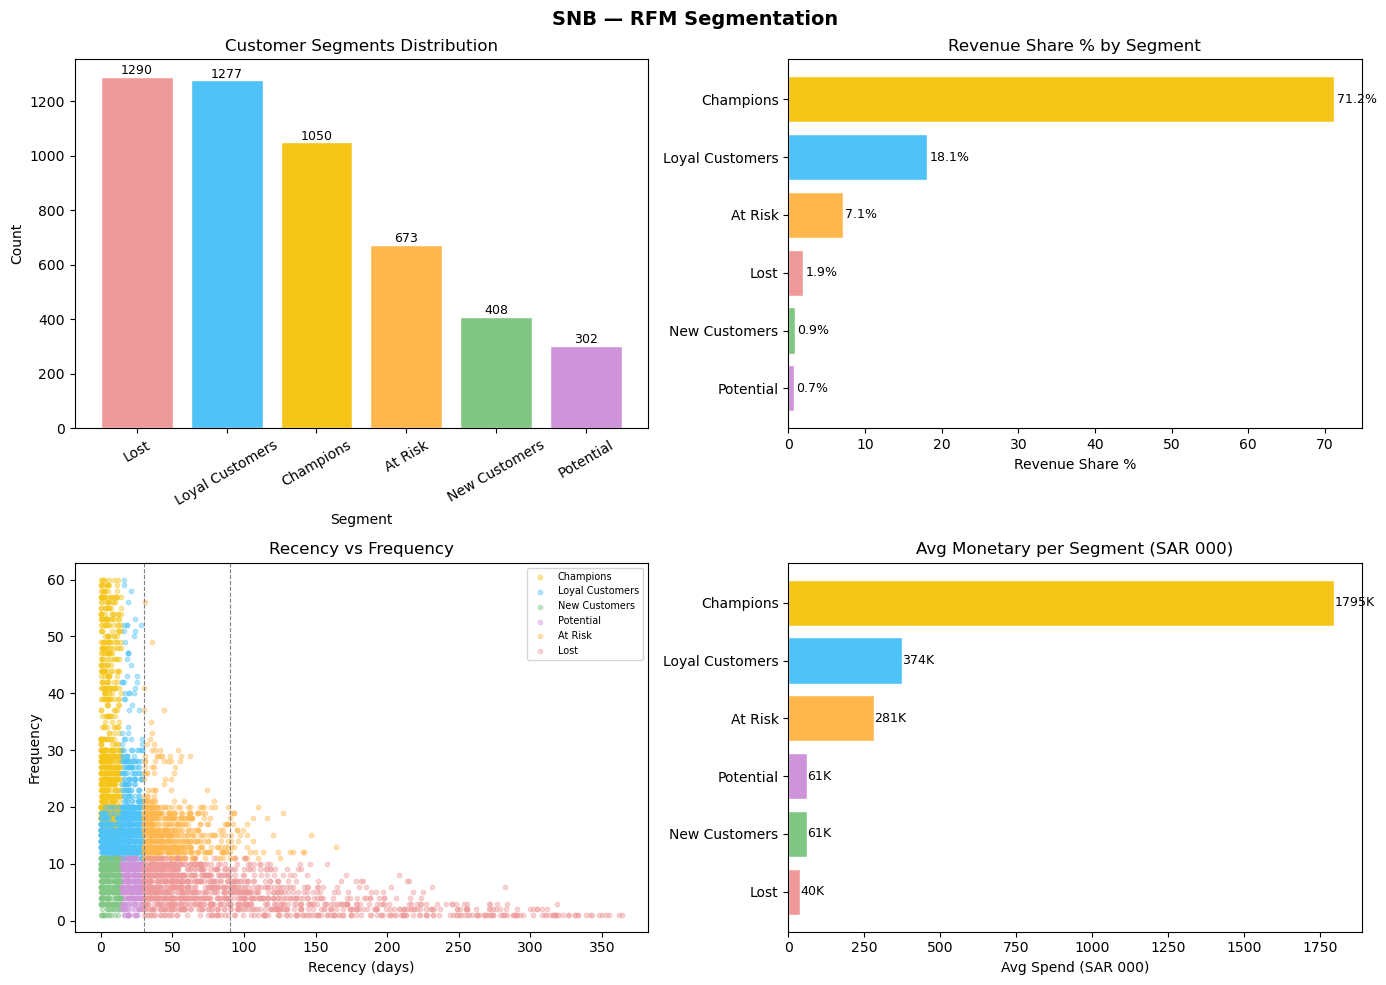

Chart saved to Outputs/chart/02_rfm_segments.png ✅


In [10]:

import os
os.makedirs('../Outputs/chart', exist_ok=True)

COLORS = {
    'Champions':       '#F5C518',
    'Loyal Customers': '#4FC3F7',
    'New Customers':   '#81C784',
    'Potential':       '#CE93D8',
    'At Risk':         '#FFB74D',
    'Lost':            '#EF9A9A',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SNB — RFM Segmentation', fontsize=14, fontweight='bold', y=0.98)

ax = axes[0, 0]
seg_counts = rfm['Segment'].value_counts()
colors = [COLORS[s] for s in seg_counts.index]
ax.bar(seg_counts.index, seg_counts.values, color=colors, edgecolor='white')
ax.set_title('Customer Segments Distribution')
ax.set_xlabel('Segment')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(seg_counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=9)

ax = axes[0, 1]
rev = summary.sort_values('Revenue_Share%')
colors_rev = [COLORS.get(s, '#888') for s in rev['Segment']]
bars = ax.barh(rev['Segment'], rev['Revenue_Share%'],
               color=colors_rev, edgecolor='white')
ax.set_title('Revenue Share % by Segment')
ax.set_xlabel('Revenue Share %')
for bar, val in zip(bars, rev['Revenue_Share%']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)

ax = axes[1, 0]
for seg, color in COLORS.items():
    sub = rfm[rfm['Segment'] == seg]
    ax.scatter(sub['Recency'], sub['Frequency'],
               color=color, alpha=0.4, s=10, label=seg)
ax.axvline(30, color='gray', lw=0.8, ls='--')
ax.axvline(90, color='gray', lw=0.8, ls='--')
ax.set_title('Recency vs Frequency')
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=7, loc='upper right')

ax = axes[1, 1]
seg_m = summary.sort_values('Avg_Monetary')
colors_m = [COLORS.get(s, '#888') for s in seg_m['Segment']]
bars = ax.barh(seg_m['Segment'], seg_m['Avg_Monetary'] / 1000,
               color=colors_m, edgecolor='white')
ax.set_title('Avg Monetary per Segment (SAR 000)')
ax.set_xlabel('Avg Spend (SAR 000)')
for bar, val in zip(bars, seg_m['Avg_Monetary'] / 1000):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../Outputs/chart/02_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Outputs/chart/02_rfm_segments.png ✅")

In [11]:

os.makedirs('../Data/clean', exist_ok=True)

rfm.to_csv('../Data/clean/snb_rfm_segments.csv',
           index=False, encoding='utf-8-sig')

summary.to_csv('../Data/clean/snb_rfm_summary.csv',
               index=False, encoding='utf-8-sig')

print("Files saved:")
print(f"Total customers segmented: {len(rfm):,}")


Files saved:
Total customers segmented: 5,000
